In [2]:
import librosa
import numpy as np
import matplotlib.pyplot as plt


In [3]:
audio_path = "songs/EppadiVandhaayo.mp3"  # change to your file

y, sr = librosa.load(audio_path, sr=None, mono=False)

print("Original Sample Rate:", sr)
print("Audio shape:", y.shape)


Original Sample Rate: 44100
Audio shape: (2, 7461888)


[src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?


In [5]:
if y.ndim == 2:
    y_mono = np.mean(y, axis=0)
else:
    y_mono = y

print("Mono shape:", y_mono.shape)



Mono shape: (7461888,)


In [ ]:
TARGET_SR = 22050

if sr != TARGET_SR:
    y_mono = librosa.resample(y_mono, orig_sr=sr, target_sr=TARGET_SR)
    sr = TARGET_SR
    print("Resampled from", sr, "to", TARGET_SR)


22050
Resampled Sample Rate: 22050


Mic distance changes the loudness
Volume does not affect the fingerprints
peak detection matters

In [9]:
y_norm = y_mono / np.max(np.abs(y_mono))

print("Max amplitude after normalization:", np.max(np.abs(y_norm)))


Max amplitude after normalization: 1.0


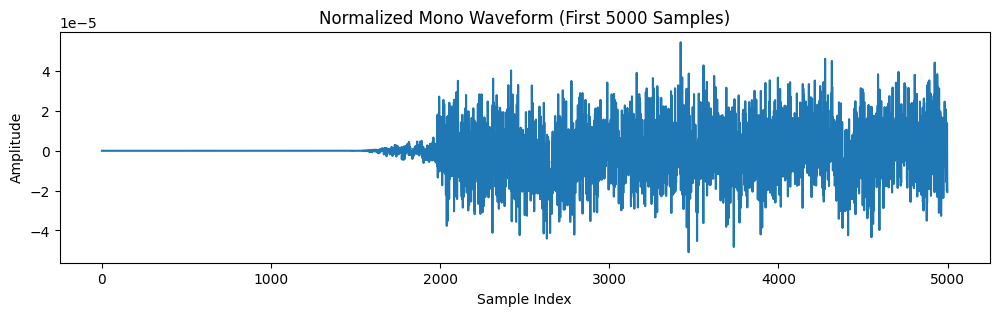

In [10]:
plt.figure(figsize=(12, 3))
plt.plot(y_norm[:5000])
plt.title("Normalized Mono Waveform (First 5000 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.show()
